# 02c_LSTM_EarlyStop (PyTorch)\n",
    "\n",
    "V, I 피처 + 고정 하이퍼파라미터 + val EarlyStopping.\n",
    "\n",
    "| 구분 | Trial |\n",
    "|---|---|\n",
    "| Train | Test1~43 (44,45 제외) |\n",
    "| Validation (EarlyStopping) | Test44, Test45 |\n",
    "| Test | Val1, Val2, Val5, Val8, Val9 |

In [8]:
from pathlib import Path

BASE_DIR  = Path.home() / 'Desktop' / 'ai1' / 'original_INC_202501'
MODEL_DIR = Path.home() / 'Desktop' / 'ai1' / 'lstm_c_model'
MODEL_DIR.mkdir(exist_ok=True)

SENSOR_INTERVAL = 0.1
WINDOW_DURATION = 3.0
STEP_DURATION   = 1.0
WINDOW_SIZE = int(WINDOW_DURATION / SENSOR_INTERVAL)   # 30
STEP_SIZE   = int(STEP_DURATION   / SENSOR_INTERVAL)   # 10
FEATURES    = ['Avg Voltage', 'Avg Current']

NORMAL_TEST_IDS   = {1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 28, 29, 30, 44}
ABNORMAL_TEST_IDS = {6, 31, 45} | set(range(32, 44))
NORMAL_VAL_IDS    = set(range(3, 10))
ABNORMAL_VAL_IDS  = {1, 2}
VAL_TRIAL_IDS     = {44, 45}

LSTM_HIDDEN_1       = 64
LSTM_HIDDEN_2       = 32
DROPOUT_RATE        = 0.3
EPOCHS              = 200
BATCH_SIZE          = 32
LEARNING_RATE       = 1e-3
EARLY_STOP_PATIENCE = 20
RANDOM_SEED         = 42

print(f'WINDOW_SIZE : {WINDOW_SIZE} samples ({WINDOW_DURATION}s)')
print(f'STEP_SIZE   : {STEP_SIZE} samples ({STEP_DURATION}s)')

WINDOW_SIZE : 30 samples (3.0s)
STEP_SIZE   : 10 samples (1.0s)


In [9]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                              average_precision_score, precision_recall_curve)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch :', torch.__version__)
print('Device  :', DEVICE)

PyTorch : 2.11.0+cu128
Device  : cuda


In [10]:
def parse_folder_id(folder_name):
    m = re.match(r'^(Test|Val)(\d+)_', folder_name, flags=re.IGNORECASE)
    if not m: return None, None
    return m.group(1).capitalize(), int(m.group(2))

def get_label(prefix, idx):
    if prefix == 'Test':
        if idx in NORMAL_TEST_IDS:   return 0
        if idx in ABNORMAL_TEST_IDS: return 1
    elif prefix == 'Val':
        if idx in NORMAL_VAL_IDS:    return 0
        if idx in ABNORMAL_VAL_IDS:  return 1
    raise ValueError(f'라벨 매핑 없음: {prefix}{idx}')

def get_split(prefix, idx):
    if prefix == 'Val':          return 'test'
    if prefix == 'Test':
        if idx in VAL_TRIAL_IDS: return 'val'
        return 'train'
    raise ValueError()

records = []
for trial_dir in sorted(BASE_DIR.iterdir()):
    if not trial_dir.is_dir(): continue
    prefix, idx = parse_folder_id(trial_dir.name)
    if prefix is None: continue
    try:
        label = get_label(prefix, idx)
        split = get_split(prefix, idx)
    except ValueError as e:
        print(f'[SKIP] {trial_dir.name}: {e}'); continue
    csvs = list(trial_dir.glob('*.csv'))
    if not csvs: continue
    data = pd.read_csv(csvs[0])[FEATURES].astype(float).values
    mean, std = data.mean(0), data.std(0)
    std[std < 1e-8] = 1e-8
    records.append({'folder': trial_dir.name, 'label': label, 'split': split,
                    'data': (data - mean) / std})
    print(f'{trial_dir.name:45s}  split={split:5s}  label={label}')

summary = pd.DataFrame([{k: r[k] for k in ('folder','split','label')} for r in records])
print('\n=== Split 요약 ===')
print(summary.groupby(['split','label']).size().rename('n_trials'))

Test1_160A_20TS_160WFR                         split=train  label=0
Test2_160A_20TS_190WFR                         split=train  label=0
Test31_120A_20TS_160WFR                        split=train  label=1
Test32_120A_20TS_190WFR                        split=train  label=1
Test34_120A_30TS_190WFR                        split=train  label=1
Test38_140A_30TS_180WFR                        split=train  label=1
Test3_160A_30TS_160WFR                         split=train  label=0
Test41_140A_25TS_180WFR                        split=train  label=1
Test43_150A_30TS_190WFR                        split=train  label=1
Test44_150A_25TS_160WFR                        split=val    label=0
Test45_150A_25TS_180WFR                        split=val    label=1
Test5_160A_40TS_160WFR                         split=train  label=0
Test7_180A_20TS_160WFR                         split=train  label=0
Test8_180A_20TS_190WFR                         split=train  label=0
Val1_130A_22TS_170WFR                          s

In [11]:
def make_windows(data, ws, ss):
    return np.stack([data[s:s+ws] for s in range(0, len(data)-ws+1, ss)])

buckets = {'train': ([], []), 'val': ([], []), 'test': ([], [])}
for r in records:
    wins   = make_windows(r['data'], WINDOW_SIZE, STEP_SIZE)
    labels = np.full(len(wins), r['label'], dtype=np.float32)
    buckets[r['split']][0].append(wins)
    buckets[r['split']][1].append(labels)

X = {s: np.vstack(buckets[s][0]).astype(np.float32) for s in buckets}
y = {s: np.concatenate(buckets[s][1]) for s in buckets}

FEAT_NAMES = ['V', 'I']
n_feat = X['train'].shape[2]   # 2

for s in ('train', 'val', 'test'):
    u, c = np.unique(y[s], return_counts=True)
    cnt  = dict(zip(u.astype(int), c))
    print(f'{s:5s}  total={len(y[s]):5d}  normal={cnt.get(0,0):5d}  abnormal={cnt.get(1,0):5d}')

train  total=  364  normal=  183  abnormal=  181
val    total=   58  normal=   29  abnormal=   29
test   total=  150  normal=   95  abnormal=   55


In [12]:
scaler = StandardScaler()
scaler.fit(X['train'].reshape(-1, n_feat))

def scale(arr):
    n, w, f = arr.shape
    return scaler.transform(arr.reshape(-1, f)).reshape(n, w, f).astype(np.float32)

Xs = {s: scale(X[s]) for s in X}

print('=== 글로벌 스케일러 통계 (train 기준) ===')
for i, name in enumerate(FEAT_NAMES):
    print(f'  {name:5s}  mean={scaler.mean_[i]:+.4f}  std={scaler.scale_[i]:.4f}')
print(f'\nX_train : {Xs["train"].shape}')
print(f'X_val   : {Xs["val"].shape}')
print(f'X_test  : {Xs["test"].shape}')

=== 글로벌 스케일러 통계 (train 기준) ===
  V      mean=+0.0204  std=0.6635
  I      mean=+0.0815  std=0.2982

X_train : (364, 30, 2)
X_val   : (58, 30, 2)
X_test  : (150, 30, 2)


In [13]:
class WindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(WindowDataset(Xs['train'], y['train']),
                           batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(WindowDataset(Xs['val'],   y['val']),
                           batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(WindowDataset(Xs['test'],  y['test']),
                           batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

Train batches : 12
Val   batches : 2
Test  batches : 5


In [14]:
class LSTMAnomalyDetector(nn.Module):
    def __init__(self, n_features, hidden1, hidden2, dropout):
        super().__init__()
        self.lstm1 = nn.LSTM(n_features, hidden1, batch_first=True)
        self.drop1 = nn.Dropout(dropout)
        self.lstm2 = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.drop2 = nn.Dropout(dropout)
        self.fc    = nn.Linear(hidden2, 1)

    def forward(self, x):
        out, _ = self.lstm1(x);  out = self.drop1(out)
        out, _ = self.lstm2(out)
        return torch.sigmoid(self.fc(self.drop2(out[:, -1, :]))).squeeze(-1)


n_feat = Xs['train'].shape[2]   # 2

model     = LSTMAnomalyDetector(n_feat, LSTM_HIDDEN_1, LSTM_HIDDEN_2, DROPOUT_RATE).to(DEVICE)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nn_features      : {n_feat}  {FEAT_NAMES}')
print(f'Trainable params: {total_params:,}')

LSTMAnomalyDetector(
  (lstm1): LSTM(2, 64, batch_first=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (lstm2): LSTM(64, 32, batch_first=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

n_features      : 2  ['V', 'I']
Trainable params: 29,985


In [15]:
# =========================
# 학습 루프 (val loss 기준 EarlyStopping, patience=20)
# =========================

best_val_loss    = float('inf')
patience_counter = 0
best_model_path  = str(MODEL_DIR / 'best_lstm.pt')
history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    tr_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward(); optimizer.step()
        tr_loss += loss.item() * len(yb)
    tr_loss /= len(train_loader.dataset)

    model.eval()
    with torch.no_grad():
        vl_loss = (sum(criterion(model(Xb.to(DEVICE)), yb.to(DEVICE)).item() * len(yb)
                       for Xb, yb in val_loader) / len(val_loader.dataset))

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS}  train_loss={tr_loss:.4f}  val_loss={vl_loss:.4f}')

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss; patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}  best_val_loss={best_val_loss:.4f}')
            break

model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
print(f'\n학습 완료  best_val_loss={best_val_loss:.4f}')

Epoch   1/200  train_loss=0.6927  val_loss=0.6934
Epoch  10/200  train_loss=0.6652  val_loss=0.7002
Epoch  20/200  train_loss=0.4753  val_loss=0.7478
Epoch  30/200  train_loss=0.3826  val_loss=0.8362
Epoch  40/200  train_loss=0.3059  val_loss=0.9099

Early stopping at epoch 42  best_val_loss=0.6588

학습 완료  best_val_loss=0.6588


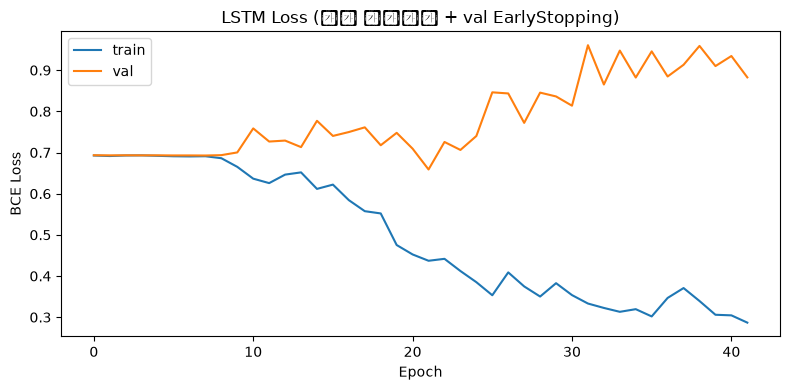

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history['train_loss'], label='train')
ax.plot(history['val_loss'],   label='val')
ax.set_title('LSTM Loss (고정 파라미터 + val EarlyStopping)')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.legend(); plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'training_curve.png'), dpi=150)
plt.show()

=== Window-level Evaluation (threshold=0.5) ===
              precision    recall  f1-score   support

   Normal(0)       0.65      0.97      0.78        95
 Abnormal(1)       0.67      0.11      0.19        55

    accuracy                           0.65       150
   macro avg       0.66      0.54      0.48       150
weighted avg       0.66      0.65      0.56       150

ROC-AUC : 0.5441
PR-AUC  : 0.4559


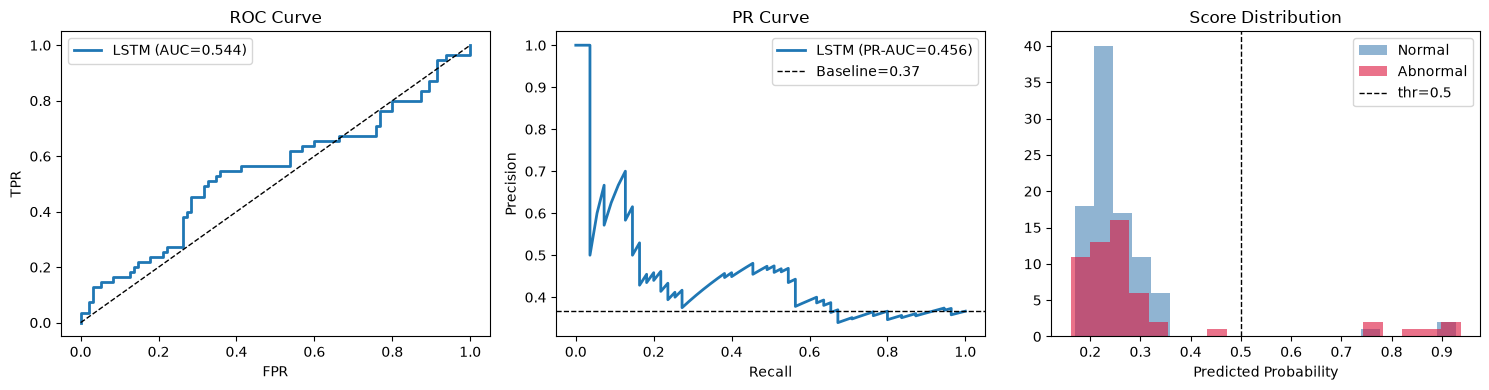

In [17]:
# =========================
# Window-level 평가 (threshold=0.5 고정)
# =========================

model.eval()
all_prob, all_true = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        all_prob.append(model(Xb.to(DEVICE)).cpu().numpy())
        all_true.append(yb.numpy())

y_prob = np.concatenate(all_prob)
y_true = np.concatenate(all_true).astype(int)
y_pred = (y_prob >= 0.5).astype(int)

roc_auc = roc_auc_score(y_true, y_prob)
pr_auc  = average_precision_score(y_true, y_prob)

print('=== Window-level Evaluation (threshold=0.5) ===')
print(classification_report(y_true, y_pred,
                             target_names=['Normal(0)', 'Abnormal(1)'],
                             zero_division=0))
print(f'ROC-AUC : {roc_auc:.4f}')
print(f'PR-AUC  : {pr_auc:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0].plot(fpr, tpr, lw=2, label=f'LSTM (AUC={roc_auc:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve'); axes[0].legend()

pre, rec, _ = precision_recall_curve(y_true, y_prob)
baseline = y_true.mean()
axes[1].plot(rec, pre, lw=2, label=f'LSTM (PR-AUC={pr_auc:.3f})')
axes[1].axhline(baseline, color='k', linestyle='--', lw=1, label=f'Baseline={baseline:.2f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curve'); axes[1].legend()

axes[2].hist(y_prob[y_true==0], bins=20, alpha=0.6, label='Normal',   color='steelblue')
axes[2].hist(y_prob[y_true==1], bins=20, alpha=0.6, label='Abnormal', color='crimson')
axes[2].axvline(0.5, color='k', linestyle='--', lw=1, label='thr=0.5')
axes[2].set_xlabel('Predicted Probability')
axes[2].set_title('Score Distribution'); axes[2].legend()

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'window_eval.png'), dpi=150)
plt.show()